In [107]:
import pandas as pd
import numpy as np


In [108]:
data = pd.read_csv("heart.xls")

In [109]:
data.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [110]:
cat_variables = []


for name in data.columns:
    size = len(data[name].unique().tolist())
    if size < 5:
        print(data[name].unique().tolist())
        cat_variables.append(name)

cat_variables

['M', 'F']
['ATA', 'NAP', 'ASY', 'TA']
[0, 1]
['Normal', 'ST', 'LVH']
['N', 'Y']
['Up', 'Flat', 'Down']
[0, 1]


['Sex',
 'ChestPainType',
 'FastingBS',
 'RestingECG',
 'ExerciseAngina',
 'ST_Slope',
 'HeartDisease']

In [111]:
non_binary = []

for column in cat_variables:
    if len(data[column].unique().tolist()) > 2:
        non_binary.append(column)

non_binary


['ChestPainType', 'RestingECG', 'ST_Slope']

In [112]:
data = pd.get_dummies(data=data, columns=non_binary)

In [113]:
data.head(5)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,M,140,289,0,172,N,0.0,0,False,True,False,False,False,True,False,False,False,True
1,49,F,160,180,0,156,N,1.0,1,False,False,True,False,False,True,False,False,True,False
2,37,M,130,283,0,98,N,0.0,0,False,True,False,False,False,False,True,False,False,True
3,48,F,138,214,0,108,Y,1.5,1,True,False,False,False,False,True,False,False,True,False
4,54,M,150,195,0,122,N,0.0,0,False,False,True,False,False,True,False,False,False,True


In [114]:
features = [x for x in data.columns if x != "HeartDisease"]
features, len(features)

(['Age',
  'Sex',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ChestPainType_ASY',
  'ChestPainType_ATA',
  'ChestPainType_NAP',
  'ChestPainType_TA',
  'RestingECG_LVH',
  'RestingECG_Normal',
  'RestingECG_ST',
  'ST_Slope_Down',
  'ST_Slope_Flat',
  'ST_Slope_Up'],
 18)

In [115]:
data[features].head(5)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,M,140,289,0,172,N,0.0,False,True,False,False,False,True,False,False,False,True
1,49,F,160,180,0,156,N,1.0,False,False,True,False,False,True,False,False,True,False
2,37,M,130,283,0,98,N,0.0,False,True,False,False,False,False,True,False,False,True
3,48,F,138,214,0,108,Y,1.5,True,False,False,False,False,True,False,False,True,False
4,54,M,150,195,0,122,N,0.0,False,False,True,False,False,True,False,False,False,True


In [116]:
from sklearn.model_selection import train_test_split

In [117]:
data["Sex"] = data["Sex"].map({
    "M": 1,
    "F": 0
})

data["ExerciseAngina"] = data["ExerciseAngina"].map({
    "Y": 1,
    "N": 0
})

In [118]:
X_train, X_test, y_train, y_test = train_test_split(data[features], data["HeartDisease"], train_size=0.8, random_state=42)

print(f'train samples: {len(X_train)}')
print(f'validation samples: {len(X_test)}')
print(f'target proportion: {sum(y_train)/len(y_train):.4f}')


train samples: 734
validation samples: 184
target proportion: 0.5463


In [119]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700] ## If the number is an integer, then it is the actual quantity of samples,
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64, None] # None means that there is no depth limit.

In [120]:
X_train.head(5)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
795,42,1,120,240,1,194,0,0.8,False,False,True,False,False,True,False,True,False,False
25,36,1,130,209,0,178,0,0.0,False,False,True,False,False,True,False,False,False,True
84,56,1,150,213,1,125,1,1.0,True,False,False,False,False,True,False,False,True,False
10,37,0,130,211,0,142,0,0.0,False,False,True,False,False,True,False,False,False,True
344,51,1,120,0,1,104,0,0.0,True,False,False,False,False,True,False,False,True,False


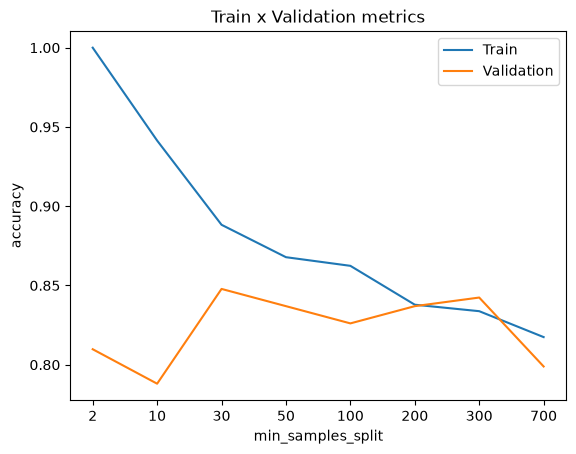

In [121]:
train_accuracy_list = []
test_accuracy_list = []


from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

for min_samples_split in min_samples_split_list:
    model = DecisionTreeClassifier(min_samples_split=min_samples_split, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    train_accuracy = accuracy_score(y_true=y_train, y_pred=y_pred)
    test_accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_test)
    train_accuracy_list.append(train_accuracy)
    test_accuracy_list.append(test_accuracy)

plt.title('Train x Validation metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list)
plt.plot(train_accuracy_list)
plt.plot(test_accuracy_list)
plt.legend(['Train','Validation'])

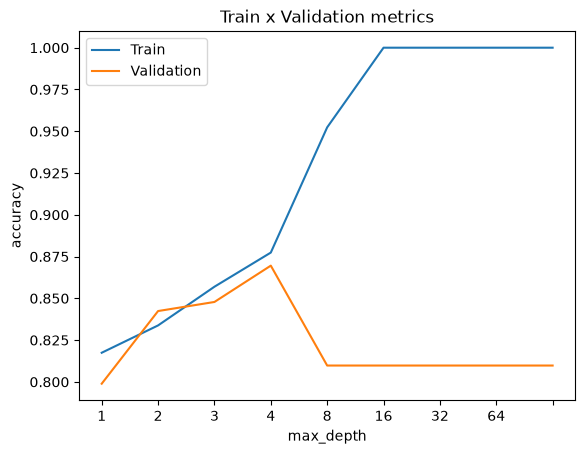

In [122]:
train_accuracy_list = []
test_accuracy_list = []

for max_depth in max_depth_list:
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    train_accuracy = accuracy_score(y_true=y_train, y_pred=y_pred)
    test_accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_test)
    train_accuracy_list.append(train_accuracy)
    test_accuracy_list.append(test_accuracy)

plt.title('Train x Validation metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(train_accuracy_list)
plt.plot(test_accuracy_list)
plt.legend(['Train','Validation'])

In [123]:
min_samples_split = 30
max_depth = 4

In [124]:
tuned_model = DecisionTreeClassifier(max_depth=max_depth,min_samples_split=min_samples_split, random_state=42)

tuned_model.fit(X=X_train, y=y_train)
y_pred = tuned_model.predict(X_train)
y_pred_test = tuned_model.predict(X_test)

training_accuracy = accuracy_score(y_true=y_train, y_pred=y_pred)
testing_accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_test)

print(f"Training Accuracy: {training_accuracy*100}\nTesting Accuracy: {testing_accuracy*100}")


Training Accuracy: 87.05722070844686
Testing Accuracy: 86.95652173913044


In [125]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]  ## If the number is an integer, then it is the actual quantity of samples,
                                             ## If it is a float, then it is the percentage of the dataset
max_depth_list = [2, 4, 8, 16, 32, 64, None]
n_estimators_list = [10,50,100,500]

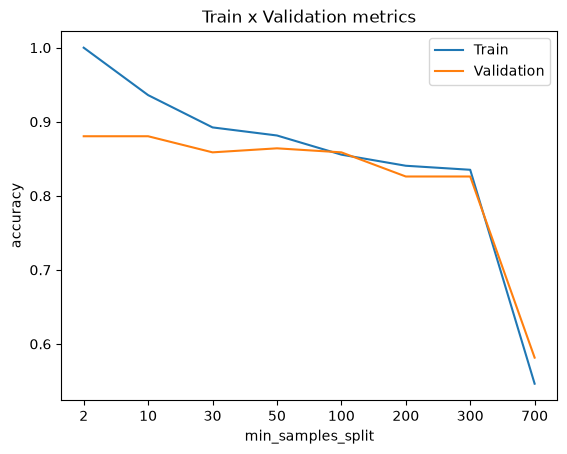

In [126]:
from sklearn.ensemble import RandomForestClassifier
training_accuracy_list = []
test_accuracy_list = []

for min_samples_split in min_samples_split_list:
    model = RandomForestClassifier(min_samples_split=min_samples_split, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    train_accuracy = accuracy_score(y_true=y_train, y_pred=y_pred)
    test_accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_test)
    training_accuracy_list.append(train_accuracy)
    test_accuracy_list.append(test_accuracy)

plt.title('Train x Validation metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list) 
plt.plot(training_accuracy_list)
plt.plot(test_accuracy_list)
plt.legend(['Train','Validation'])

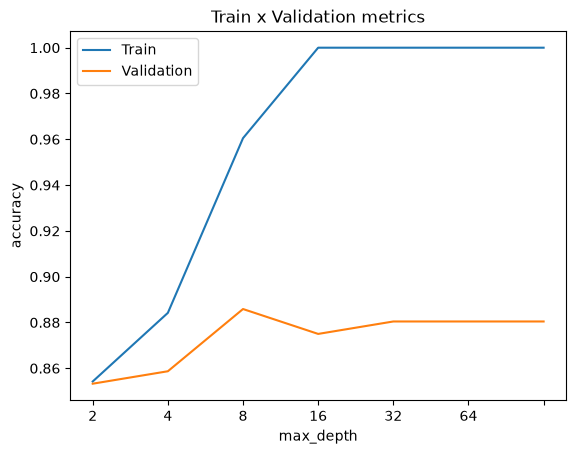

In [127]:
min_samples_split = 100

training_accuracy_list = []
test_accuracy_list = []

for max_depth in max_depth_list:
    model = RandomForestClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    train_accuracy = accuracy_score(y_true=y_train, y_pred=y_pred)
    test_accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_test)
    training_accuracy_list.append(train_accuracy)
    test_accuracy_list.append(test_accuracy)

plt.title('Train x Validation metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(training_accuracy_list)
plt.plot(test_accuracy_list)
plt.legend(['Train','Validation'])


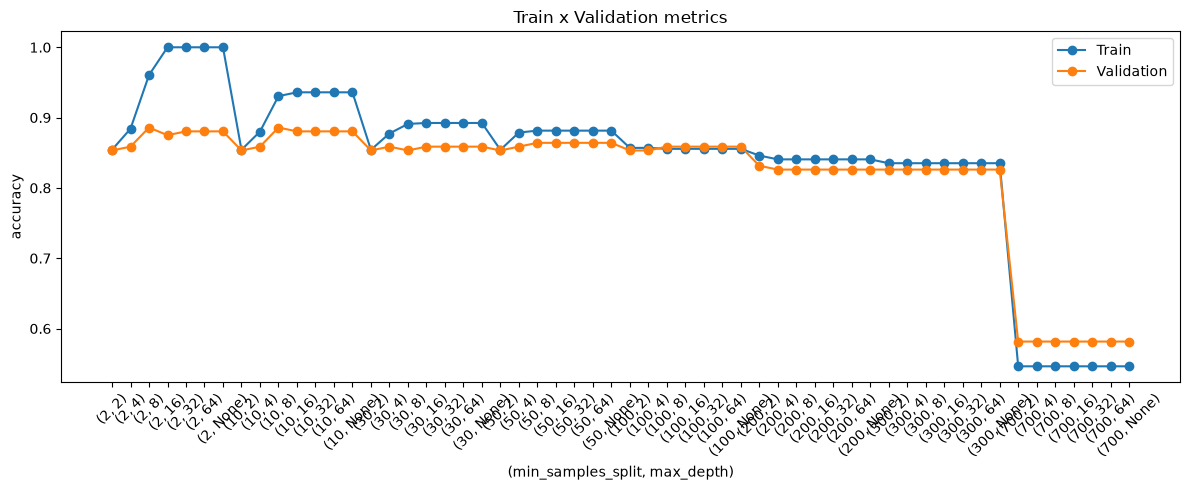

In [128]:
max_depth = 4

training_accuracy_list = []
test_accuracy_list = []
from itertools import product

pairs = list(product(min_samples_split_list, max_depth_list))
for (min_samples_split, max_depth) in pairs:
    model = RandomForestClassifier(min_samples_split=min_samples_split,max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    train_accuracy = accuracy_score(y_true=y_train, y_pred=y_pred)
    test_accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_test)
    training_accuracy_list.append(train_accuracy)
    test_accuracy_list.append(test_accuracy)

x = range(len(pairs))

pair_labels = [
    f"({min_split}, {depth})"
    for min_split, depth in pairs
]

plt.figure(figsize=(12, 5))

plt.plot(
    x,
    training_accuracy_list,
    marker='o',
    label='Train'
)

plt.plot(
    x,
    test_accuracy_list,
    marker='o',
    label='Validation'
)

plt.title('Train x Validation metrics')
plt.xlabel('(min_samples_split, max_depth)')
plt.ylabel('accuracy')

plt.xticks(x, pair_labels, rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

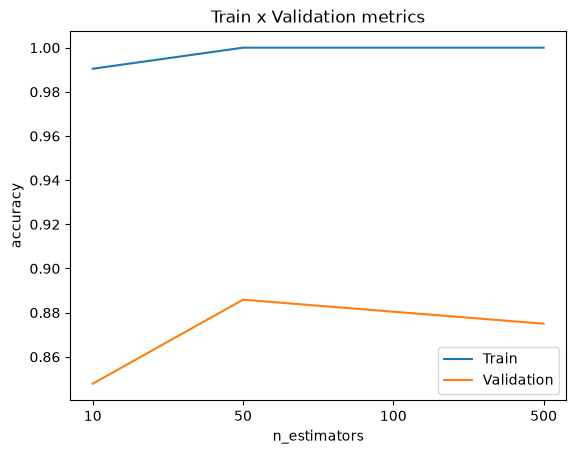

In [129]:
training_accuracy_list = []
test_accuracy_list = []

for n_estimators in n_estimators_list:
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    train_accuracy = accuracy_score(y_true=y_train, y_pred=y_pred)
    test_accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_test)
    training_accuracy_list.append(train_accuracy)
    test_accuracy_list.append(test_accuracy)

plt.title('Train x Validation metrics')
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(n_estimators_list )),labels=n_estimators_list)
plt.plot(training_accuracy_list)
plt.plot(test_accuracy_list)
plt.legend(['Train','Validation'])

In [135]:
n_estimators = 100

tuned_random_forest = RandomForestClassifier(n_estimators=50, max_depth=4, min_samples_split=100, random_state=42)
tuned_random_forest.fit(X_train, y_train)
y_pred = tuned_random_forest.predict(X_train)
y_pred_test = tuned_random_forest.predict(X_test)
train_accuracy = accuracy_score(y_true=y_train, y_pred=y_pred)
test_accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_test)

print(f"Training Accuracy: {train_accuracy*100}\nTesting Accuracy: {test_accuracy*100}")

Training Accuracy: 85.01362397820164
Testing Accuracy: 85.32608695652173


In [131]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    "min_samples_split": [2, 10, 30, 50, 100, 200, 300, 700],
    "max_depth": [2, 4, 8, 16, 32, 64, None],
    "n_estimators": [10, 50, 100, 500]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 4, ...], 'min_samples_split': [2, 10, ...], 'n_estimators': [10, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [132]:
print(grid_search.best_params_)
print(grid_search.best_score_)


tuned_random_forest = grid_search.best_estimator_
y_pred = tuned_random_forest.predict(X_train)
y_pred_test = tuned_random_forest.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Train accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)

{'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 500}
0.8691827415897866
Train accuracy: 0.9591280653950953
Test accuracy: 0.8858695652173914


In [ ]:
n = int(len(X_train)*0.8) ## Let's use 80% to train and 20% to eval
X_train_fit, X_train_eval, y_train_fit, y_train_eval = X_train[:n], X_train[n:], y_train[:n], y_train[n:]

In [143]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators = 500, learning_rate = 0.1,verbosity = 1, random_state = 42, early_stopping_rounds = 10)
xgb_model.fit(X_train_fit,y_train_fit, eval_set = [(X_train_eval,y_train_eval)])

[0]	validation_0-logloss:0.65147
[1]	validation_0-logloss:0.61294
[2]	validation_0-logloss:0.57975
[3]	validation_0-logloss:0.55176
[4]	validation_0-logloss:0.53179
[5]	validation_0-logloss:0.51404
[6]	validation_0-logloss:0.49887
[7]	validation_0-logloss:0.48811
[8]	validation_0-logloss:0.47910
[9]	validation_0-logloss:0.47019
[10]	validation_0-logloss:0.46102
[11]	validation_0-logloss:0.45350
[12]	validation_0-logloss:0.44869
[13]	validation_0-logloss:0.44373
[14]	validation_0-logloss:0.44140
[15]	validation_0-logloss:0.43771
[16]	validation_0-logloss:0.43603
[17]	validation_0-logloss:0.43263
[18]	validation_0-logloss:0.43099
[19]	validation_0-logloss:0.42716
[20]	validation_0-logloss:0.42804
[21]	validation_0-logloss:0.42717
[22]	validation_0-logloss:0.42610
[23]	validation_0-logloss:0.42524
[24]	validation_0-logloss:0.42592
[25]	validation_0-logloss:0.42088
[26]	validation_0-logloss:0.41736
[27]	validation_0-logloss:0.41674
[28]	validation_0-logloss:0.41551
[29]	validation_0-loglos

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [144]:
xgb_model.best_iteration

29

In [148]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(xgb_model.predict(X_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(xgb_model.predict(X_test),y_test):.4f}")

Metrics train:
	Accuracy score: 0.9387
Metrics test:
	Accuracy score: 0.8696
